# Questão 1

--- Informações Extraídas ---
Quantização: 16 bits
Total de amostras no arquivo: 21958
Taxa de Amostragem: 8012 Hz, Período de Amostragem: 0.00012481278082875687 s


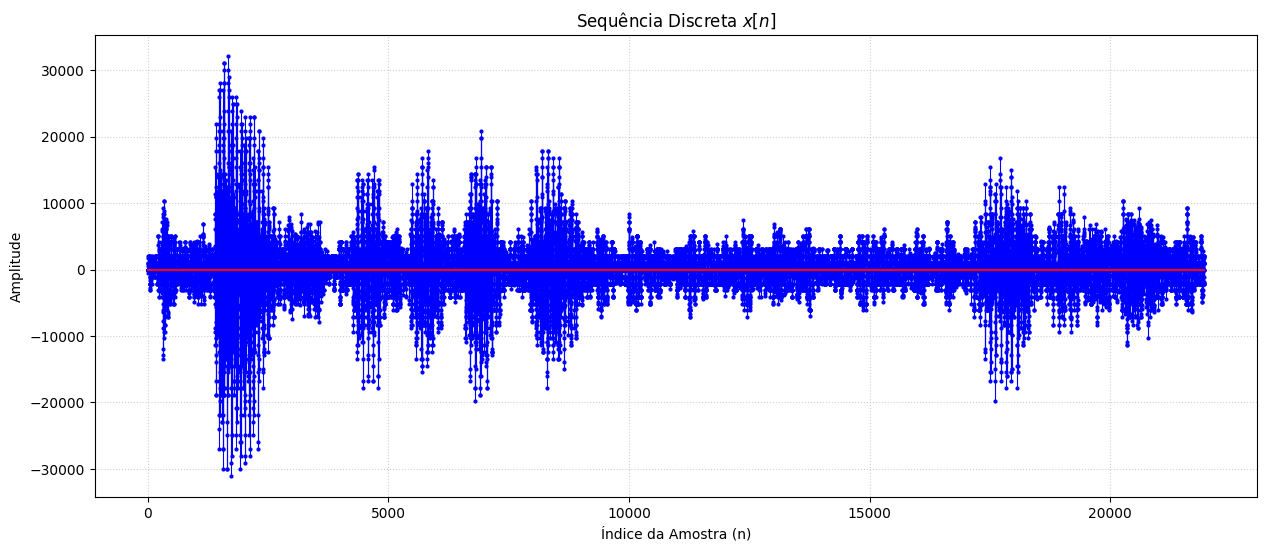

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

NOME_ARQUIVO = '../data/forcewithyou.wav'


try:
    samplerate, data = wavfile.read(NOME_ARQUIVO)

    if len(data.shape) > 1:
        data = data[:, 0]

    # 2. Extrair informações
    bits_quantizacao = data.dtype.itemsize * 8
    num_amostras_total = data.shape[0]

    inicio = 0
    fim = data.shape[0]
    n_fragmento = np.arange(inicio, fim)
    data_fragmento = data[inicio:fim]


    x_n = {
        'x': data,
        'N': data.shape[0],
        'Resolution': bits_quantizacao,
        'fs': samplerate,
        'ts': 1/samplerate
    }

    print(f"--- Informações Extraídas ---")
    print(f"Quantização: {x_n['Resolution']} bits")
    print(f"Total de amostras no arquivo: {x_n['N']}")
    print(f"Taxa de Amostragem: {x_n['fs']} Hz, Período de Amostragem: {x_n['ts']} s")

    def plot_x_n(x_n, i, f, title):
        plt.figure(figsize=(15, 6))

        markerline, stemlines, baseline = plt.stem(np.arange(i, f), x_n['x'],
                                                linefmt='b-', markerfmt='.', basefmt='r-')

        plt.setp(stemlines, 'linewidth', 0.8)
        plt.setp(markerline, 'markersize', 4)

        plt.title(title)
        plt.xlabel("Índice da Amostra (n)")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle=':', alpha=0.6)


    plot_x_n(x_n, 0, x_n['N'], f"Sequência Discreta $x[n]$")
    plt.show()

except FileNotFoundError:
    print(f"Arquivo '{NOME_ARQUIVO}' não encontrado.")

# Questão 2

## (a)

128


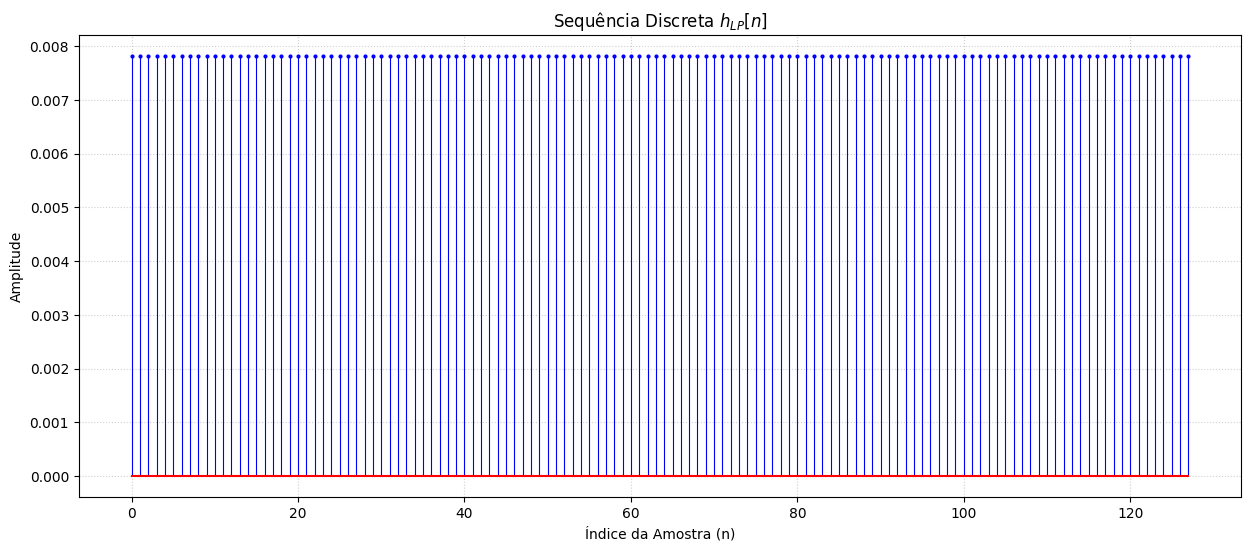

In [ ]:
M = 128
h_lp_n = np.ones(M) * (1/M)
print(len(h_lp_n))

h_lp_n = {
    'x': h_lp_n,
    'N': M,
    'Resolution': bits_quantizacao,
    'fs': samplerate,
    'ts': 1/samplerate
}

plot_x_n(h_lp_n, 0, h_lp_n['N'], "Sequência Discreta $h_{LP}[n]$")
plt.show()


## (b)

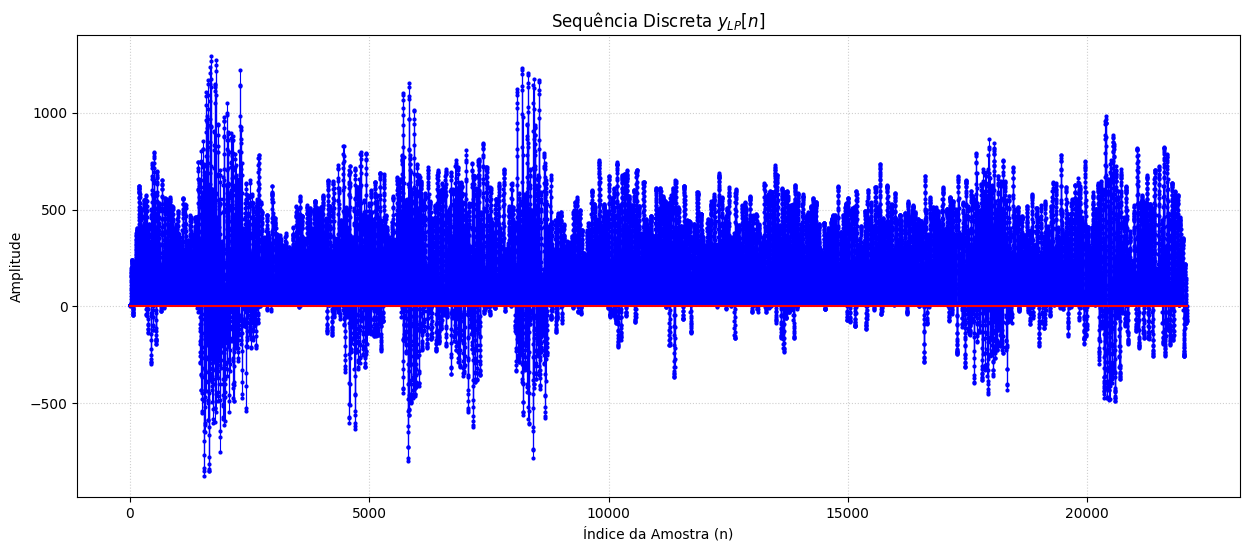

In [ ]:
def conv_linear(x_n, h_n):
    y_n = []
    for n in range( x_n['N'] + h_n['N'] - 1 ):
        soma = 0
        for l in range( x_n['N'] ):
            if 0 <= n-l < M - 1:
                soma+= x_n['x'][l] * h_n['x'][n-l]
            else:
                soma+=0

        y_n.append(soma)
    y_n = np.array(y_n)
    y_n = {
        'x': y_n,
        'N': x_n['N'] + h_n['N'] - 1,
        'Resolution': bits_quantizacao,
        'fs': samplerate,
        'ts': 1/samplerate
    }
    return y_n

y_lp_n = conv_linear(x_n, h_lp_n)

plot_x_n(y_lp_n, 0, y_lp_n['N'], "Sequência Discreta $y_{LP}[n]$")
plt.show()

## (c)

In [ ]:
def salvar_x_n(x_n, nome_arquivo="x_n.wav"):
    """
    Recebe o dicionário e salva um arquivo .wav
    """

    sinal = x_n['x']
    fs = x_n['fs']

    max_val = np.max(np.abs(sinal))

    if max_val > 0:
        sinal_normalizado = sinal / max_val
    else:
        sinal_normalizado = sinal

    sinal_int16 = (sinal_normalizado * 32767).astype(np.int16)

    wavfile.write(nome_arquivo, fs, sinal_int16)
    print(f"Sucesso! Arquivo '{nome_arquivo}' salvo com {x_n['N']} amostras.")

salvar_x_n(y_lp_n, "../data/forcewithyou_lp.wav")

Sucesso! Arquivo '../data/forcewithyou_lp.wav' salvo com 22085 amostras.


## (d)

128


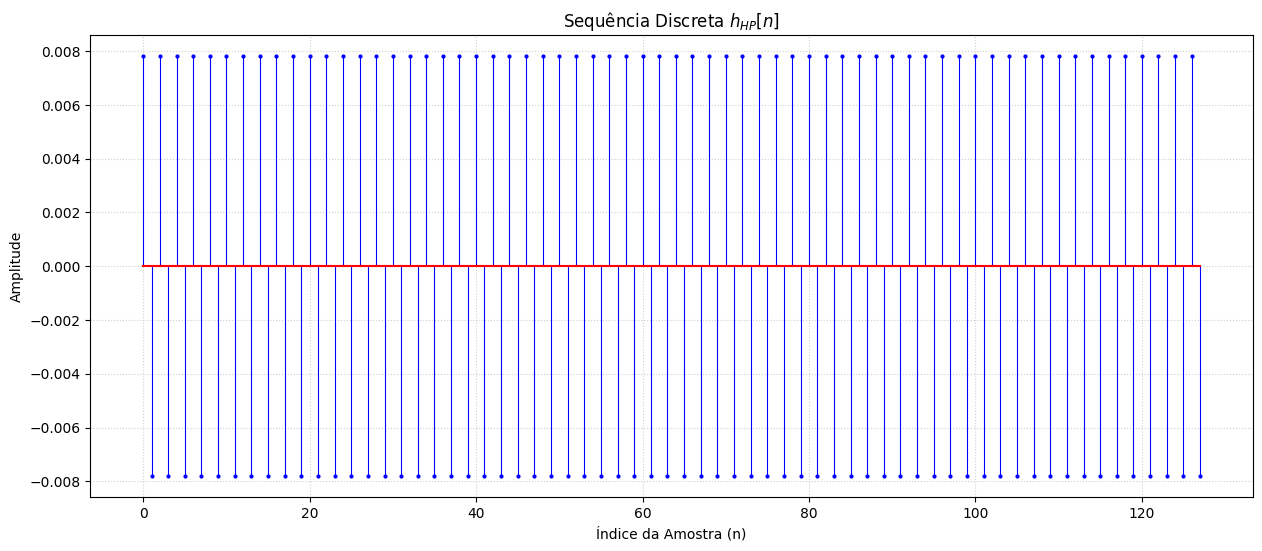

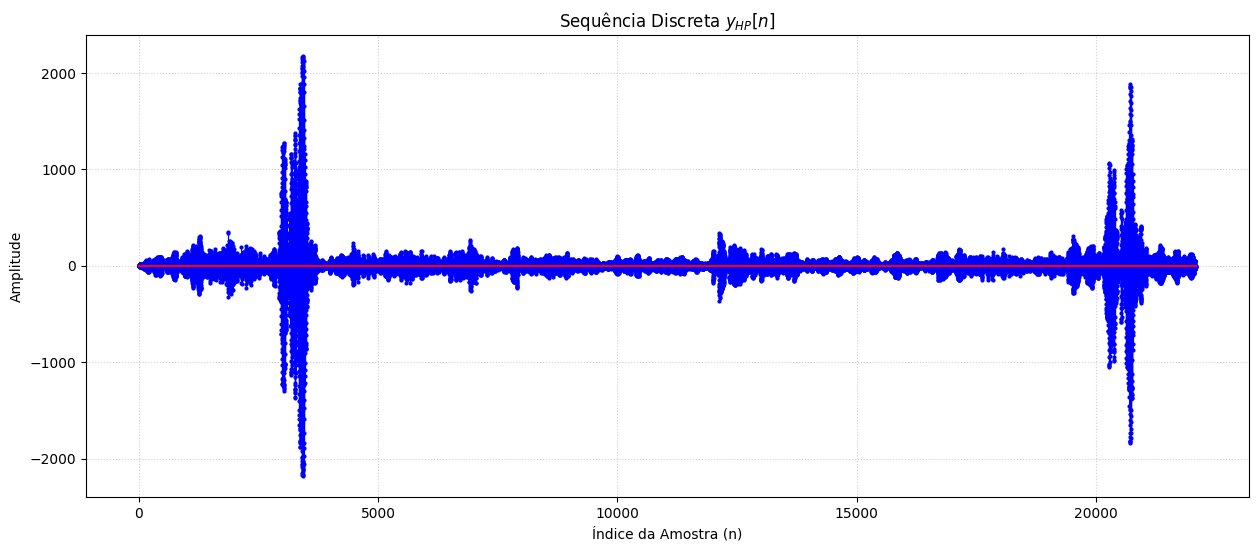

Sucesso! Arquivo '../data/forcewithyou_hp.wav' salvo com 22085 amostras.


In [ ]:
M = 128
h_hp_n = np.array([((-1)**n) * h_lp_n['x'][n] for n in range(M)])
print(len(h_hp_n))

h_hp_n = {
    'x': h_hp_n,
    'N': M,
    'Resolution': bits_quantizacao,
    'fs': samplerate,
    'ts': 1/samplerate
}

plot_x_n(h_hp_n, 0, h_hp_n['N'], "Sequência Discreta $h_{HP}[n]$")
plt.show()

y_hp_n = conv_linear(x_n, h_hp_n)
plot_x_n(y_hp_n, 0, y_hp_n['N'], "Sequência Discreta $y_{HP}[n]$")
plt.show()

salvar_x_n(y_hp_n, "../data/forcewithyou_hp.wav")

##Questão 3

#(a)

Frequencia mínima: '108.5'
Período mínima: '0.009217'
Período final: '0.073733'


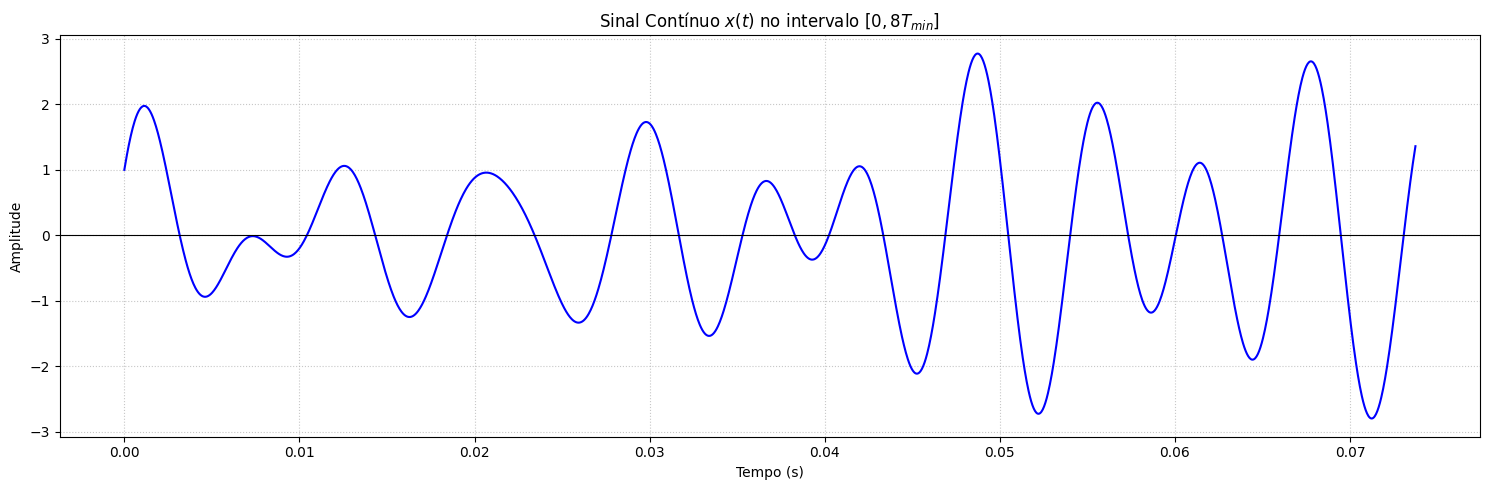

In [ ]:
f_min = 217 / 2
t_min = 1 / f_min
t_final = 8 * t_min

t = np.linspace(0, t_final, 2000)

x_t = np.sin(300 * np.pi * t) + np.cos(325 * np.pi * t) + np.sin(217 * np.pi * t)



plt.figure(figsize=(15, 5))
plt.plot(t, x_t, color='blue', linewidth=1.5)


plt.title("Sinal Contínuo $x(t)$ no intervalo $[0, 8T_{min}]$")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':', alpha=0.7)

plt.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
print(f"Frequencia mínima: '{f_min}'")
print(f"Período mínima: '{t_min:6f}'")
print(f"Período final: '{t_final:6f}'")

plt.show()


#(b)

Frequencia máxima: '162.500000
Frequencia amostrada: '81.250000
Período amostrado: '0.012308
Total de amostras: '6


/tmp/ipykernel_9126/1024422314.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


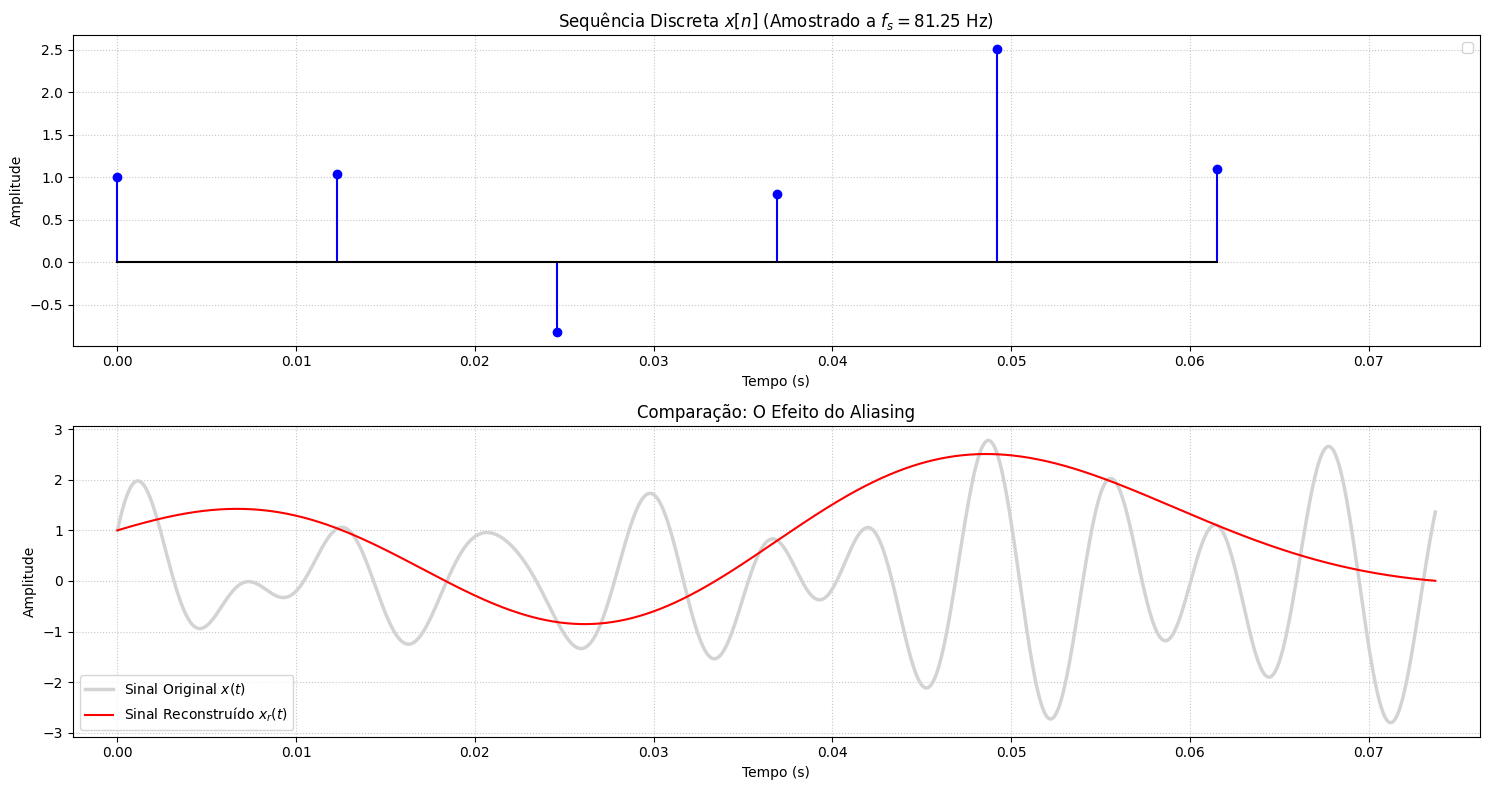

In [ ]:
f_max = 325 / 2
f_s = f_max/2
T_s = 1 / f_s

print(f"Frequencia máxima: '{f_max:6f}")
print(f"Frequencia amostrada: '{f_s:6f}")
print(f"Período amostrado: '{T_s:6f}")


n = np.arange(0, int(t_final / T_s) + 1)
print(f"Total de amostras: '{n.size}")
t_n = n * T_s


x_n = np.sin(300 * np.pi * t_n) + np.cos(325 * np.pi * t_n) + np.sin(217 * np.pi * t_n)

x_r = np.zeros_like(t)
for i, t_amostra in enumerate(t_n):
    x_r += x_n[i] * np.sinc(f_s * (t - t_amostra))

plt.figure(figsize=(15, 8))


plt.subplot(2, 1, 1)
# plt.plot(t, x_t, color='lightgray', alpha=0.5, label='Sinal x(t) invisível ao computador')
plt.stem(t_n, x_n, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Sequência Discreta $x[n]$ (Amostrado a $f_s = 81.25$ Hz)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(t, x_t, color='lightgray', linewidth=2.5, label='Sinal Original $x(t)$')
plt.plot(t, x_r, color='red', linestyle='-', linewidth=1.5, label='Sinal Reconstruído $x_r(t)$')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Comparação: O Efeito do Aliasing")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#O sinal reconstruído é totalmente diferente do sinal original

#(c)

Frequencia máxima: '162.500000
Frequencia amostrada: '325.000000
Período amostrado: '0.003077
Total de amostras: '24


/tmp/ipykernel_9126/3538033663.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


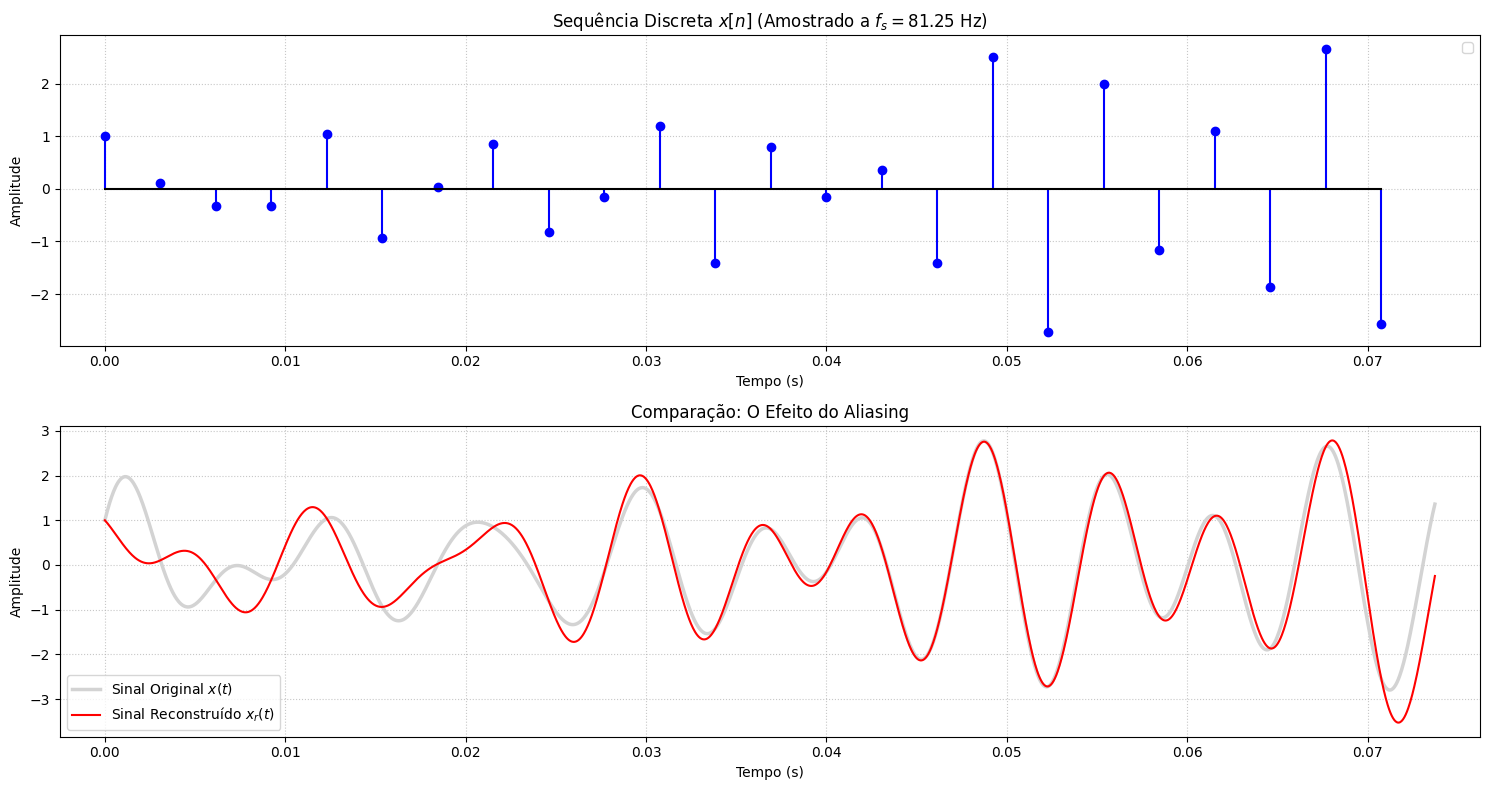

In [ ]:
f_max = 325 / 2
f_s = f_max*2
T_s = 1 / f_s

print(f"Frequencia máxima: '{f_max:6f}")
print(f"Frequencia amostrada: '{f_s:6f}")
print(f"Período amostrado: '{T_s:6f}")


n = np.arange(0, int(t_final / T_s) + 1)
print(f"Total de amostras: '{n.size}")
t_n = n * T_s


x_n = np.sin(300 * np.pi * t_n) + np.cos(325 * np.pi * t_n) + np.sin(217 * np.pi * t_n)

x_r = np.zeros_like(t)
for i, t_amostra in enumerate(t_n):
    x_r += x_n[i] * np.sinc(f_s * (t - t_amostra))

plt.figure(figsize=(15, 8))


plt.subplot(2, 1, 1)
# plt.plot(t, x_t, color='lightgray', alpha=0.5, label='Sinal x(t) invisível ao computador')
plt.stem(t_n, x_n, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Sequência Discreta $x[n]$ (Amostrado a $f_s = 81.25$ Hz)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(t, x_t, color='lightgray', linewidth=2.5, label='Sinal Original $x(t)$')
plt.plot(t, x_r, color='red', linestyle='-', linewidth=1.5, label='Sinal Reconstruído $x_r(t)$')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Comparação: O Efeito do Aliasing")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#Apesar de ter algumas diferenças, principalmente quando o período é menor (frequência é maior), o sinal reconstruído se assemelha ao sinal original. Porém ainda há perdas de informações.




#(d)

Frequencia máxima: '162.500000
Frequencia amostrada: '650.000000
Período amostrado: '0.001538
Total de amostras: '48


/tmp/ipykernel_9126/1767267027.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


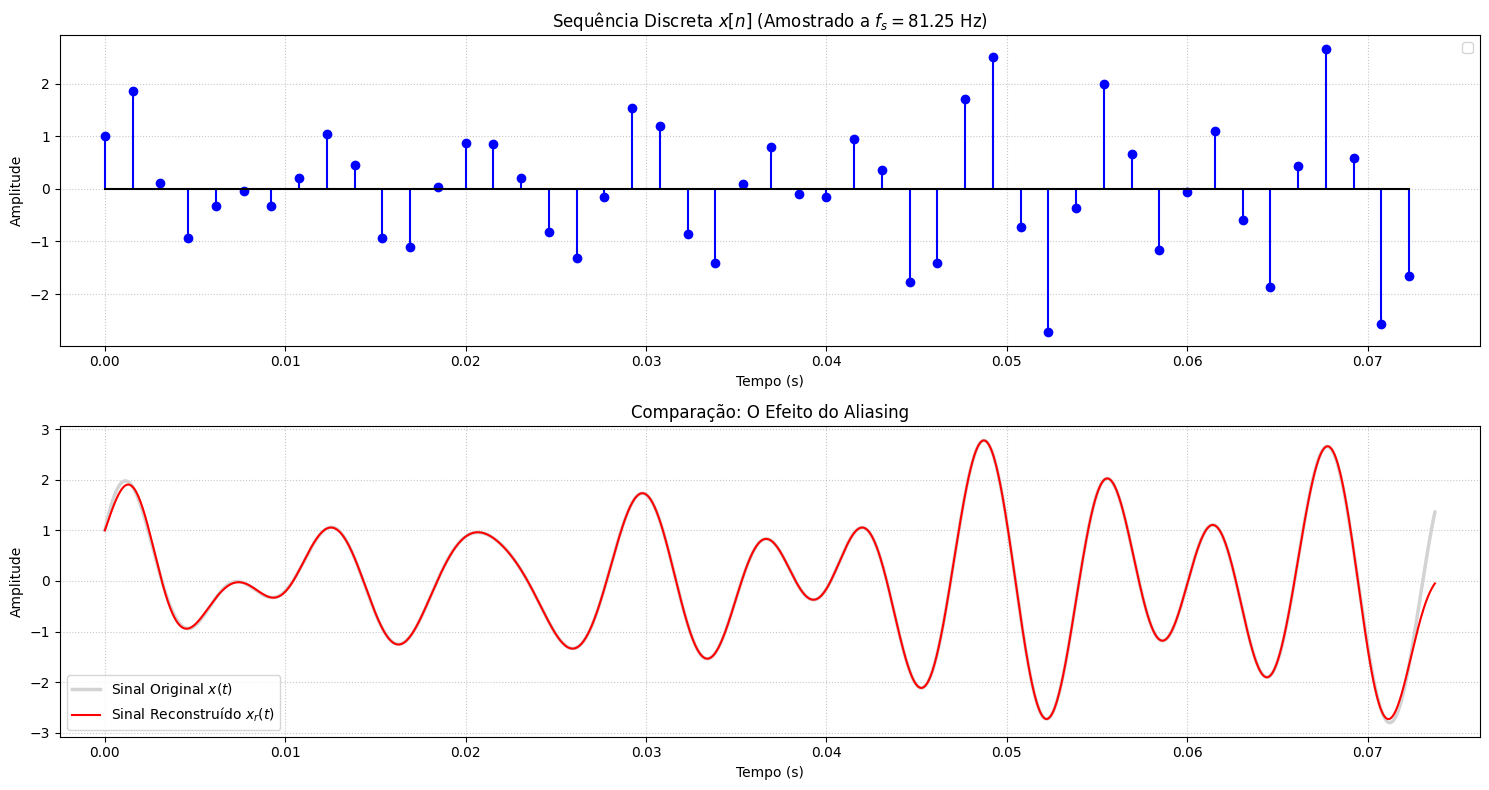

In [ ]:
f_max = 325 / 2
f_s = f_max * 4
T_s = 1 / f_s

print(f"Frequencia máxima: '{f_max:6f}")
print(f"Frequencia amostrada: '{f_s:6f}")
print(f"Período amostrado: '{T_s:6f}")


n = np.arange(0, int(t_final / T_s) + 1)
print(f"Total de amostras: '{n.size}")
t_n = n * T_s


x_n = np.sin(300 * np.pi * t_n) + np.cos(325 * np.pi * t_n) + np.sin(217 * np.pi * t_n)

x_r = np.zeros_like(t)
for i, t_amostra in enumerate(t_n):
    x_r += x_n[i] * np.sinc(f_s * (t - t_amostra))

plt.figure(figsize=(15, 8))


plt.subplot(2, 1, 1)
# plt.plot(t, x_t, color='lightgray', alpha=0.5, label='Sinal x(t) invisível ao computador')
plt.stem(t_n, x_n, linefmt='b-', markerfmt='bo', basefmt='k-')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Sequência Discreta $x[n]$ (Amostrado a $f_s = 81.25$ Hz)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(t, x_t, color='lightgray', linewidth=2.5, label='Sinal Original $x(t)$')
plt.plot(t, x_r, color='red', linestyle='-', linewidth=1.5, label='Sinal Reconstruído $x_r(t)$')
plt.xlim(-0.0025, t_final+0.0025)
plt.title("Comparação: O Efeito do Aliasing")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

#O sinal reconstruído apresenta bastante semelhança com o sinal original, havendo, em grande parte de sua extensão, pouca ou nenhuma perda de informação


